# Module & Data Loading

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [109]:
df = pd.read_csv('/content/IBM HR Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [110]:
df.shape

(1470, 35)

# Data Cleaning

## Null Values

In [111]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**No Null Values**



---



## Data Types

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Accurate Data Types**



---



## Duplicated Values

In [113]:
df.duplicated().sum()

np.int64(0)

**No Duplicated Values**



---



## Cleaning Summary

In [114]:
print('Data Cleaning Summary')
print('---------------------')
print('Number of Rows:', df.shape[0])
print('Number of Columns:', df.shape[1])
print('Number of Duplicated Rows:', df.duplicated().sum())
print('Number of Missing Values:', df.isnull().sum().sum())

Data Cleaning Summary
---------------------
Number of Rows: 1470
Number of Columns: 35
Number of Duplicated Rows: 0
Number of Missing Values: 0




---


---




# Analysis
### *Theory: People are leaving because they are underpaid.*

## Attrition vs Monthly Income

In [115]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


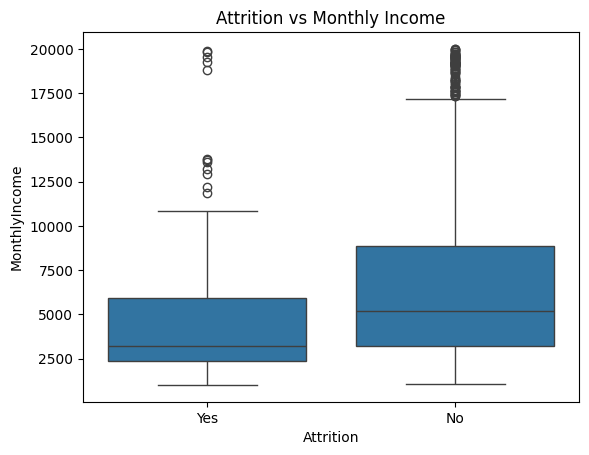

In [116]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition vs Monthly Income')
plt.show()

In [117]:
attrition_avg= round(df.groupby('Attrition')['MonthlyIncome'].mean(),2)
attrition_avg

,MonthlyIncome
Attrition,
No,6832.74
Yes,4787.09


**we have 16.12% Attrition Rate with average 4787$ Monthly Income 30% les than retaind Employess average Monthly Income**



---



## Attrition vs Years Since Last Promotion

In [118]:
print(df.groupby('Attrition')['YearsSinceLastPromotion'].agg(
    ['mean', 'min', 'max','median']
))

               mean  min  max  median
Attrition                            
No         2.234388    0   15     1.0
Yes        1.945148    0   15     1.0


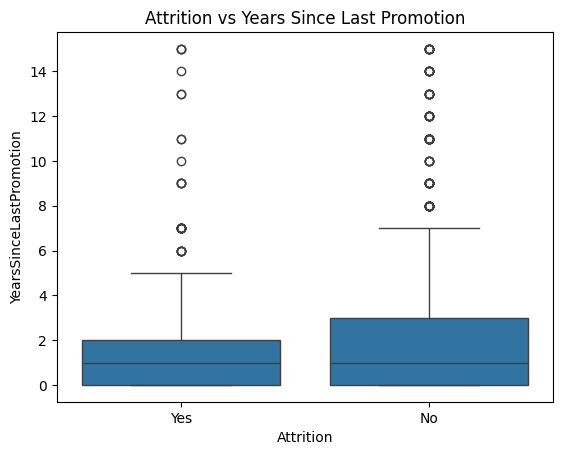

In [119]:
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df)
plt.title('Attrition vs Years Since Last Promotion')
plt.show()

Both groups have a median of 1.0 years. People who stay and people who leave get promoted at roughly the same speed.

**promotions aren't the problem.**



---



## Attrition Vs Overtime

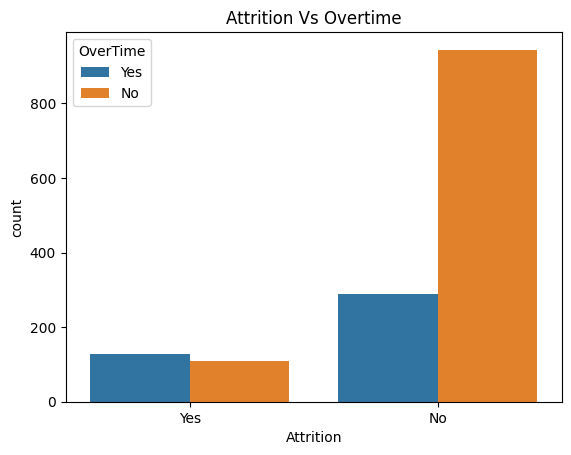

In [120]:
sns.countplot(x='Attrition', hue='OverTime', data=df)
plt.title('Attrition Vs Overtime')
plt.show()

In [121]:

crosstab_table = pd.crosstab(df['Attrition'], df['OverTime'])
print(crosstab_table)

OverTime    No  Yes
Attrition          
No         944  289
Yes        110  127


Text(0.5, 1.0, 'Attrition, Overtime Cross Tab')

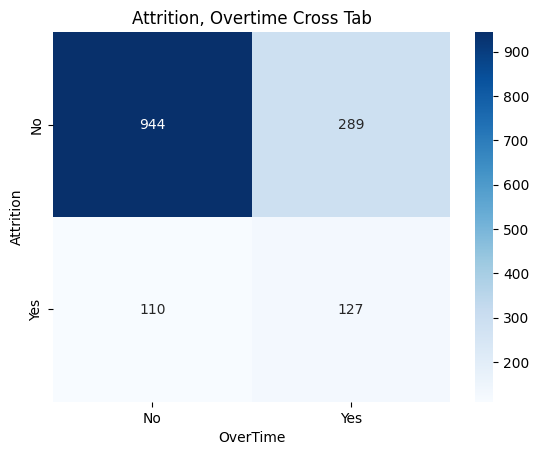

In [122]:
sns.heatmap(crosstab_table, annot=True, cmap='Blues', fmt='g')
plt.title('Attrition, Overtime Cross Tab')


1. People who DO NOT work Overtime: Attrition Rate: $110 / (944 + 110) =$ 10.4%
2. People who DO work Overtime: Attrition Rate: $127 / (289 + 127) =$ 30.5%

**employees who work overtime are 3 times more likely to quit (30.5% vs 10.4%) than those who work normal hours.**



---



## Correlation

### Numeric Columns

In [123]:
# Encode Attrition to numbers
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# correlations
correlations = df[numerical_cols].corr()

# Attrition
print(correlations['Attrition_Num'].sort_values(ascending=False))

Attrition_Num               1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

### Categorical Columns

In [124]:
categorical_cols = ['JobRole', 'MaritalStatus', 'EducationField', 'Department', 'BusinessTravel']

for col in categorical_cols:
    print(f"\n--- Attrition by {col} ---")
    print(df.groupby(col)['Attrition_Num'].mean().sort_values(ascending=False))


--- Attrition by JobRole ---
JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition_Num, dtype: float64

--- Attrition by MaritalStatus ---
MaritalStatus
Single      0.255319
Married     0.124814
Divorced    0.100917
Name: Attrition_Num, dtype: float64

--- Attrition by EducationField ---
EducationField
Human Resources     0.259259
Technical Degree    0.242424
Marketing           0.220126
Life Sciences       0.146865
Medical             0.135776
Other               0.134146
Name: Attrition_Num, dtype: float64

--- Attrition by Department ---
Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition_Num, dty



---



## Age vs. Income by Attrition

In [125]:
attrition_yes= df[df['Attrition']=='Yes']
attrition_no= df[df['Attrition']=='No']

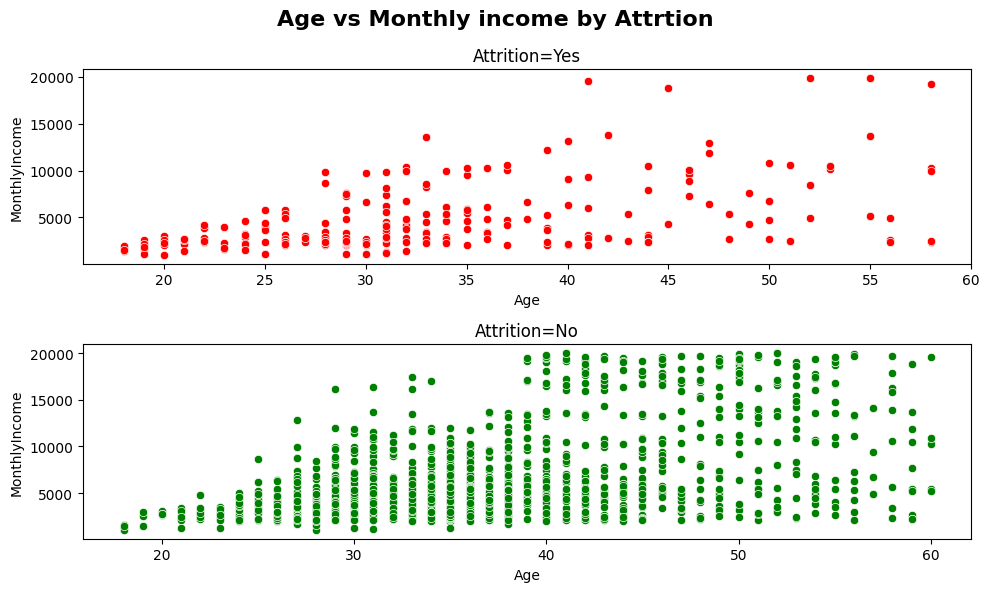

In [126]:
fig, ax = plt.subplots(2,1,figsize=(10, 6))


ax1=sns.scatterplot(attrition_yes,x='Age',y='MonthlyIncome',color='red',ax=ax[0])
ax2=sns.scatterplot(attrition_no,x='Age',y='MonthlyIncome',color='green',ax=ax[1])
fig.suptitle('Age vs Monthly income by Attrtion', fontsize=16, fontweight='bold')
ax1.set_title('Attrition=Yes')
ax2.set_title('Attrition=No')
plt.tight_layout()


**The company is bleeding Young, Low-Paid Talent.**


---



## Overtime by Role

In [127]:
# Overtime Yes = 1, Overtime No = 0
overtime_by_role = df.groupby('JobRole')['OverTime'].apply(lambda x: (x == 1).mean())
print('\/-----Overtime By Job Role-----\/')

print(overtime_by_role.sort_values(ascending=False))

\/-----Overtime By Job Role-----\/
JobRole
Healthcare Representative    0.0
Human Resources              0.0
Laboratory Technician        0.0
Manager                      0.0
Manufacturing Director       0.0
Research Director            0.0
Research Scientist           0.0
Sales Executive              0.0
Sales Representative         0.0
Name: OverTime, dtype: float64


**Research Scientists:** #1 in Overtime (33%), but their Attrition is "only" 16%.

**Sales Representatives:** #2 in Overtime (29%), but their Attrition is massive (40%).

In [128]:
# Overtime Yes = 1, Overtime No = 0
income_by_role = df.groupby('JobRole')['MonthlyIncome'].mean()
print('\/-----Income By Job Role-----\/')
print(round(income_by_role.sort_values(ascending=True),2))

\/-----Income By Job Role-----\/
JobRole
Sales Representative          2626.00
Laboratory Technician         3237.17
Research Scientist            3239.97
Human Resources               4235.75
Sales Executive               6924.28
Manufacturing Director        7295.14
Healthcare Representative     7528.76
Research Director            16033.55
Manager                      17181.68
Name: MonthlyIncome, dtype: float64


**Sales Representatives has the lowest average income in the entire company ($2,626).**

**Overtime**: Sales Reps work the 2nd most overtime (29%).

**Pay**: Sales Reps get the lowest pay ($2,626).

**Result**: Sales Reps have the highest Attrition (40%).



---



# Final Phase: The Predictive Model (Machine Learning)

### Data Preparation

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Drop useless columns (ID numbers don't predict behavior)
df_clean = df.drop(['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1)

# Convert all text columns to numbers using Label Encoding
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

X = df_clean.drop(['Attrition', 'Attrition_Num'], axis=1) # All columns except 'Attrition'
y = df_clean['Attrition'] # Only 'Attrition'


print("Data is ready for training!")

Data is ready for training!


### Model Building

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")

Accuracy: 88.10%


### Feature Importance

               Feature  Importance
15       MonthlyIncome    0.078212
18            OverTime    0.066669
0                  Age    0.061569
2            DailyRate    0.054087
23   TotalWorkingYears    0.052491
16         MonthlyRate    0.048373
9           HourlyRate    0.047369
4     DistanceFromHome    0.045999
26      YearsAtCompany    0.041347
17  NumCompaniesWorked    0.037951


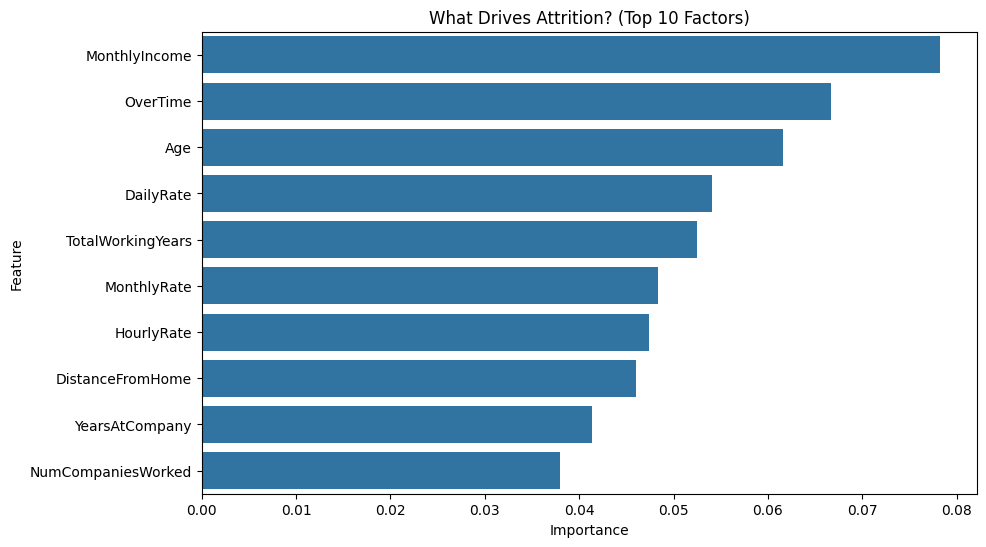

In [140]:
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("What Drives Attrition? (Top 10 Factors)")
plt.show()



---


**The model predicts with 88% accuracy that attrition is driven by a combination of Low Pay and Burnout, specifically targeting our Younger Workforce.**


---



**While we cannot change an employee's Age, we can control their Pay and Overtime hours. This is where we should focus our retention budget.**


---

